In [1]:
import pandas as pd
import numpy as np

In [3]:
np.random.seed(42)

n = 150

project_type = np.random.choice(
    ["Residential", "Commercial", "Office", "Retail"],
    n
)

area = np.random.randint(1000, 8001, n)

floors = np.random.randint(1, 6, n)

complexity = np.random.choice(
    ["Low", "Medium", "High"],
    n,
    p=[0.3, 0.5, 0.2]
)

duration = np.random.randint(3, 13, n)

location = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    n,
    p=[0.5, 0.3, 0.2]
)

complexity_cost = {
    "Low": 0,
    "Medium": 15000,
    "High": 35000
}

location_cost = {
    "Urban": 20000,
    "Suburban": 10000,
    "Rural": 0
}

type_cost = {
    "Residential": 10000,
    "Commercial": 30000,
    "Office": 25000,
    "Retail": 20000
}

project_cost = (
    area * 25
    + floors * 12000
    + duration * 3000
    + np.array([complexity_cost[x] for x in complexity])
    + np.array([location_cost[x] for x in location])
    + np.array([type_cost[x] for x in project_type])
    + np.random.normal(0, 10000, n)
)

project_cost = np.round(project_cost, 0)

df = pd.DataFrame({
    "Project_ID": [f"P{i:03d}" for i in range(1, n + 1)],
    "Project_Type": project_type,
    "Area_sqft": area,
    "Floors": floors,
    "Complexity": complexity,
    "Duration_Months": duration,
    "Location": location,
    "Project_Cost": project_cost
})

df.head()

,Project_ID,Project_Type,Area_sqft,Floors,Complexity,Duration_Months,Location,Project_Cost
0,P001,Office,6794,1,Low,7,Rural,227133.0
1,P002,Retail,5514,1,Low,8,Rural,183612.0
2,P003,Residential,7432,4,High,5,Suburban,316684.0
3,P004,Office,5474,3,Medium,10,Rural,247495.0
4,P005,Office,6892,5,Low,3,Suburban,270703.0


In [4]:
df.shape

(150, 8)

In [5]:
df.describe

<bound method NDFrame.describe of     Project_ID Project_Type  Area_sqft  Floors Complexity  Duration_Months  \
0         P001       Office       6794       1        Low                7   
1         P002       Retail       5514       1        Low                8   
2         P003  Residential       7432       4       High                5   
3         P004       Office       5474       3     Medium               10   
4         P005       Office       6892       5        Low                3   
..         ...          ...        ...     ...        ...              ...   
145       P146       Office       1197       1     Medium                3   
146       P147       Office       2930       2        Low                9   
147       P148       Office       4582       5       High                7   
148       P149  Residential       7895       2     Medium                7   
149       P150       Retail       7287       2        Low                4   

     Location  Project_Cost  

In [6]:
df.to_csv("architecture_projects.csv", index=False)

In [7]:
df.dtypes

Project_ID             str
Project_Type           str
Area_sqft            int32
Floors               int32
Complexity             str
Duration_Months      int32
Location               str
Project_Cost       float64
dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Area <= 0:", (df["Area_sqft"] <= 0).sum())
print("Floors <= 0:", (df["Floors"] <= 0).sum())
print("Duration <= 0:", (df["Duration_Months"] <= 0).sum())
print("Cost <= 0:", (df["Project_Cost"] <= 0).sum())

Area <= 0: 0
Floors <= 0: 0
Duration <= 0: 0
Cost <= 0: 0


In [10]:
df.describe()

,Area_sqft,Floors,Duration_Months,Project_Cost
count,150.000000,150.000000,150.000000,150.000000
mean,4828.680000,2.820000,7.226667,224429.826667
std,1931.981937,1.385786,2.901392,55701.129508
min,1197.000000,1.000000,3.000000,106778.000000
25%,3179.250000,2.000000,5.000000,182012.750000
50%,4755.500000,3.000000,7.000000,229791.500000
75%,6565.000000,4.000000,10.000000,264208.750000
max,7938.000000,5.000000,12.000000,341919.000000


In [11]:
df["Project_Type"].value_counts()

Project_Type
Retail         46
Commercial     36
Office         34
Residential    34
Name: count, dtype: int64

In [12]:
df["Complexity"].value_counts()

Complexity
Medium    76
Low       47
High      27
Name: count, dtype: int64

In [13]:
df["Location"].value_counts()

Location
Urban       68
Suburban    54
Rural       28
Name: count, dtype: int64

In [14]:
df.groupby("Project_Type")["Project_Cost"].mean().sort_values(ascending=False)

Project_Type
Residential    232944.617647
Commercial     227869.055556
Retail         221660.108696
Office         216020.764706
Name: Project_Cost, dtype: float64

In [15]:
df[[
    "Area_sqft",
    "Floors",
    "Duration_Months",
    "Project_Cost"
]].corr()

,Area_sqft,Floors,Duration_Months,Project_Cost
Area_sqft,1.000000,-0.005893,0.145731,0.893874
Floors,-0.005893,1.000000,-0.148359,0.280474
Duration_Months,0.145731,-0.148359,1.000000,0.209016
Project_Cost,0.893874,0.280474,0.209016,1.000000


In [16]:
df.groupby("Complexity")["Project_Cost"].mean().sort_values(ascending=False)

Complexity
High      238358.148148
Medium    232594.710526
Low       203225.659574
Name: Project_Cost, dtype: float64

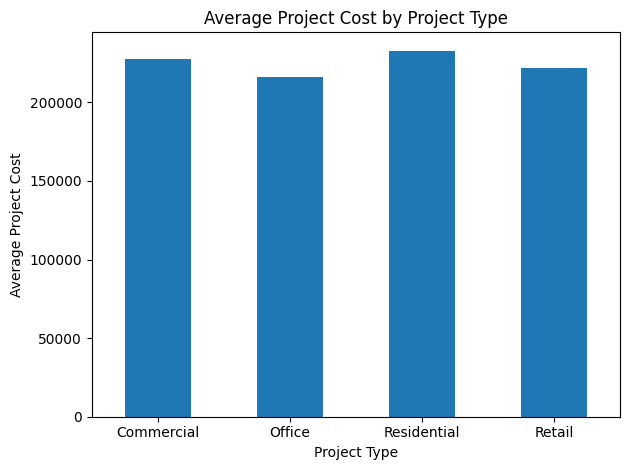

In [17]:
import matplotlib.pyplot as plt

avg_cost = df.groupby("Project_Type")["Project_Cost"].mean()

avg_cost.plot(kind="bar")

plt.title("Average Project Cost by Project Type")
plt.xlabel("Project Type")
plt.ylabel("Average Project Cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.9.1


In [19]:
X = df[
    [
        "Project_Type",
        "Area_sqft",
        "Floors",
        "Complexity",
        "Duration_Months",
        "Location"
    ]
]

y = df["Project_Cost"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())



Features:
  Project_Type  Area_sqft  Floors Complexity  Duration_Months  Location
0       Office       6794       1        Low                7     Rural
1       Retail       5514       1        Low                8     Rural
2  Residential       7432       4       High                5  Suburban
3       Office       5474       3     Medium               10     Rural
4       Office       6892       5        Low                3  Suburban

Target:
0    227133.0
1    183612.0
2    316684.0
3    247495.0
4    270703.0
Name: Project_Cost, dtype: float64


In [20]:
X_encoded = pd.get_dummies(
    X,
    columns=["Project_Type", "Complexity", "Location"],
    drop_first=True
)

X_encoded.head()

,Area_sqft,Floors,Duration_Months,Project_Type_Office,Project_Type_Residential,Project_Type_Retail,Complexity_Low,Complexity_Medium,Location_Suburban,Location_Urban
0,6794,1,7,True,False,False,True,False,False,False
1,5514,1,8,False,False,True,True,False,False,False
2,7432,4,5,False,True,False,False,False,True,False
3,5474,3,10,True,False,False,False,True,False,False
4,6892,5,3,True,False,False,True,False,True,False


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 120
Testing records: 30


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [23]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[170798.82347913 130969.60253802 224931.155055   154831.936096
 293862.38921576 328650.38522268 203157.8800605  147686.07740637
 287221.67143172 188838.34406109]


In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R² Score:", round(r2, 3))

Mean Absolute Error: 11053.29
R² Score: 0.958


In [25]:
results = pd.DataFrame({
    "Actual_Cost": y_test.values,
    "Predicted_Cost": y_pred
})

results["Difference"] = (
    results["Actual_Cost"] - results["Predicted_Cost"]
)

results.head(10)

,Actual_Cost,Predicted_Cost,Difference
0,192222.0,170798.823479,21423.176521
1,137302.0,130969.602538,6332.397462
2,249990.0,224931.155055,25058.844945
3,151632.0,154831.936096,-3199.936096
4,290501.0,293862.389216,-3361.389216
5,324299.0,328650.385223,-4351.385223
6,201380.0,203157.880060,-1777.880060
7,149560.0,147686.077406,1873.922594
8,299612.0,287221.671432,12390.328568
9,183991.0,188838.344061,-4847.344061


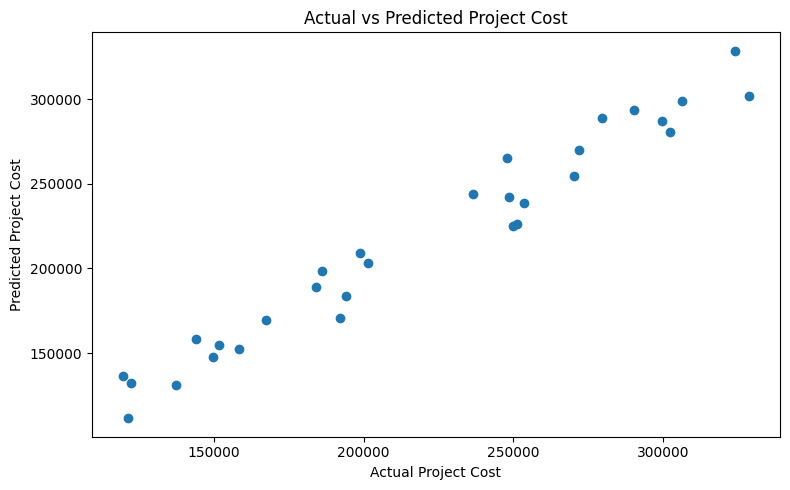

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Project Cost")
plt.ylabel("Predicted Project Cost")
plt.title("Actual vs Predicted Project Cost")

plt.tight_layout()
plt.show()

In [27]:
results = X_test.copy()

results["Actual_Cost"] = y_test
results["Predicted_Cost"] = y_pred

results.head(10)

,Area_sqft,Floors,Duration_Months,Project_Type_Office,Project_Type_Residential,Project_Type_Retail,Complexity_Low,Complexity_Medium,Location_Suburban,Location_Urban,Actual_Cost,Predicted_Cost
73,2663,3,3,False,False,False,False,True,False,True,192222.0,170798.823479
18,1804,2,5,False,False,True,False,True,True,False,137302.0,130969.602538
118,5097,2,7,False,False,True,False,False,False,False,249990.0,224931.155055
78,3237,2,5,True,False,False,True,False,True,False,151632.0,154831.936096
76,6592,3,7,False,False,True,False,False,False,True,290501.0,293862.389216
31,7910,4,11,False,True,False,False,True,False,True,324299.0,328650.385223
64,4060,4,6,True,False,False,True,False,True,False,201380.0,203157.880060
141,1766,4,3,False,True,False,False,True,False,True,149560.0,147686.077406
68,6739,3,4,False,False,True,False,False,False,True,299612.0,287221.671432
82,5029,1,7,False,True,False,True,False,False,True,183991.0,188838.344061


In [28]:
results["Difference"] = (
    results["Actual_Cost"] - results["Predicted_Cost"]
)

results.head(10)

,Area_sqft,Floors,Duration_Months,Project_Type_Office,Project_Type_Residential,Project_Type_Retail,Complexity_Low,Complexity_Medium,Location_Suburban,Location_Urban,Actual_Cost,Predicted_Cost,Difference
73,2663,3,3,False,False,False,False,True,False,True,192222.0,170798.823479,21423.176521
18,1804,2,5,False,False,True,False,True,True,False,137302.0,130969.602538,6332.397462
118,5097,2,7,False,False,True,False,False,False,False,249990.0,224931.155055,25058.844945
78,3237,2,5,True,False,False,True,False,True,False,151632.0,154831.936096,-3199.936096
76,6592,3,7,False,False,True,False,False,False,True,290501.0,293862.389216,-3361.389216
31,7910,4,11,False,True,False,False,True,False,True,324299.0,328650.385223,-4351.385223
64,4060,4,6,True,False,False,True,False,True,False,201380.0,203157.880060,-1777.880060
141,1766,4,3,False,True,False,False,True,False,True,149560.0,147686.077406,1873.922594
68,6739,3,4,False,False,True,False,False,False,True,299612.0,287221.671432,12390.328568
82,5029,1,7,False,True,False,True,False,False,True,183991.0,188838.344061,-4847.344061


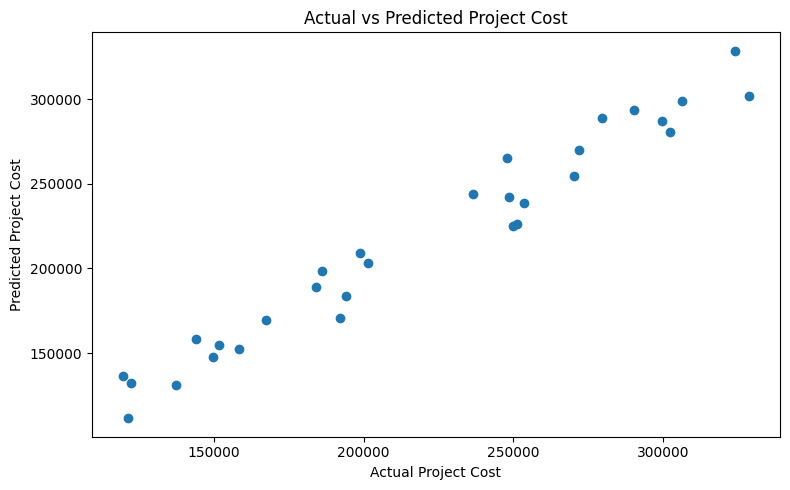

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Project Cost")
plt.ylabel("Predicted Project Cost")
plt.title("Actual vs Predicted Project Cost")

plt.tight_layout()
plt.show()

In [30]:
results.to_csv("project_cost_predictions.csv", index=False)

In [31]:
new_project = pd.DataFrame({
    "Project_Type": ["Residential"],
    "Area_sqft": [3000],
    "Floors": [2],
    "Complexity": ["High"],
    "Duration_Months": [7],
    "Location": ["Urban"]
})

new_project

,Project_Type,Area_sqft,Floors,Complexity,Duration_Months,Location
0,Residential,3000,2,High,7,Urban


In [32]:
new_project_encoded = pd.get_dummies(
    new_project,
    columns=["Project_Type", "Complexity", "Location"],
    drop_first=True
)

new_project_encoded = new_project_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

In [33]:
predicted_cost = model.predict(new_project_encoded)[0]

print("Predicted Project Cost:", round(predicted_cost, 2))

Predicted Project Cost: 176681.64


In [34]:
new_project["Predicted_Cost"] = predicted_cost

new_project.to_csv(
    "new_project_prediction.csv",
    index=False
)

In [35]:
prediction_results = df.loc[X_test.index, [
    "Project_ID",
    "Project_Type",
    "Area_sqft",
    "Floors",
    "Complexity",
    "Duration_Months",
    "Location",
    "Project_Cost"
]].copy()

prediction_results["Predicted_Cost"] = y_pred

prediction_results["Difference"] = (
    prediction_results["Project_Cost"]
    - prediction_results["Predicted_Cost"]
)

prediction_results.rename(
    columns={"Project_Cost": "Actual_Cost"},
    inplace=True
)

prediction_results.to_csv(
    "project_cost_predictions_clean.csv",
    index=False
)

prediction_results.head()

,Project_ID,Project_Type,Area_sqft,Floors,Complexity,Duration_Months,Location,Actual_Cost,Predicted_Cost,Difference
73,P074,Commercial,2663,3,Medium,3,Urban,192222.0,170798.823479,21423.176521
18,P019,Retail,1804,2,Medium,5,Suburban,137302.0,130969.602538,6332.397462
118,P119,Retail,5097,2,High,7,Rural,249990.0,224931.155055,25058.844945
78,P079,Office,3237,2,Low,5,Suburban,151632.0,154831.936096,-3199.936096
76,P077,Retail,6592,3,High,7,Urban,290501.0,293862.389216,-3361.389216
